# Propagation of a Soliton of the Korteweg–De Vries Equation

Program propagates a soliton of the Korteweg–De Vries equation.

## Korteweg–De Vries Equation

The simulated partial differential equation is

\begin{equation}
\frac{\partial y}{\partial t} + 6y\frac{\partial y}{\partial x} + \frac{\partial^3 y}{\partial x^3}=0
\end{equation}

The analytical soliton solution is

\begin{equation}
y(x,t)=\frac{c}{2}\,\mathrm{sech}^2\left(\frac{\sqrt{c}}{2}(x-x_0-ct)\right)
\end{equation}

The equation is solved numerically with a **finite-difference method**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Functions

## Analytical Soliton Solution

### Formula
\begin{equation}
y(x,t)=\frac{c}{2}\,\mathrm{sech}^2\left(\frac{\sqrt{c}}{2}(x-x_0-ct)\right)
\end{equation}

In [2]:
def sech(x):
    return 1/np.cosh(x)

# analytical solution of a KdV soliton at fixed time t
def KdVSoliton(x,t,c,x0,NG):
    y = 0.5*c*sech(0.5*np.sqrt(c)*(x[:NG]-x0-c*t))**2
    return y

## Parameters

In [3]:
L = 40                     # Length of the water line

NG = 401                   # Number of spatial grid points
dx = L/(NG-1)              # Distance between two grid points
x = np.arange(0, NG)*dx

Tmax = 20.                 # Maximum time
NT = 100001                # Number of time steps
dt = Tmax/(NT-1)           # Time step
t = np.arange(0, NT)*dt    # Time grid

## Prepare Grid

In [4]:
y = np.zeros((NT, NG))

## Initial Conditions

In [5]:
# Initial condition: soliton with velocity c
c = 1.
y[0,:] = KdVSoliton(x,0,c,10,NG)

# Second time step required for symmetric form of the discrete derivative
# The soliton has moved forward by dt with velocity c
y[1,:] = KdVSoliton(x,dt,c,10,NG)

## Solution of the Differential Equation

### Finite Difference Scheme

The discretized KdV equation used here:

$$
y_j^i = y_{j-2}^i - \frac{dt}{dx}
\left(6 y_{j-1}^i (y_x) + \frac{y_{xxx}}{dx^2} \right)
$$

with

$$
y_x = y_{j-1}^{i+1}-y_{j-1}^{i-1}
$$

$$
y_{xxx} = y_{j-1}^{i+2}-2y_{j-1}^{i+1}+2y_{j-1}^{i-1}-y_{j-1}^{i-2}
$$

In [6]:
# Solve the PDE using the finite-difference method
for j in range(2, NT):

    yx = y[j-1, 3:NG-1] - y[j-1, 1:NG-3]

    yx3 = (
        y[j-1, 4:NG]
        - 2*y[j-1, 3:NG-1]
        + 2*y[j-1, 1:NG-3]
        - y[j-1, 0:NG-4])

    y[j, 2:NG-2] = y[j-2, 2:NG-2] - (dt/dx) * (6 * y[j-1, 2:NG-2] * yx + yx3 / dx**2)

## Visualization

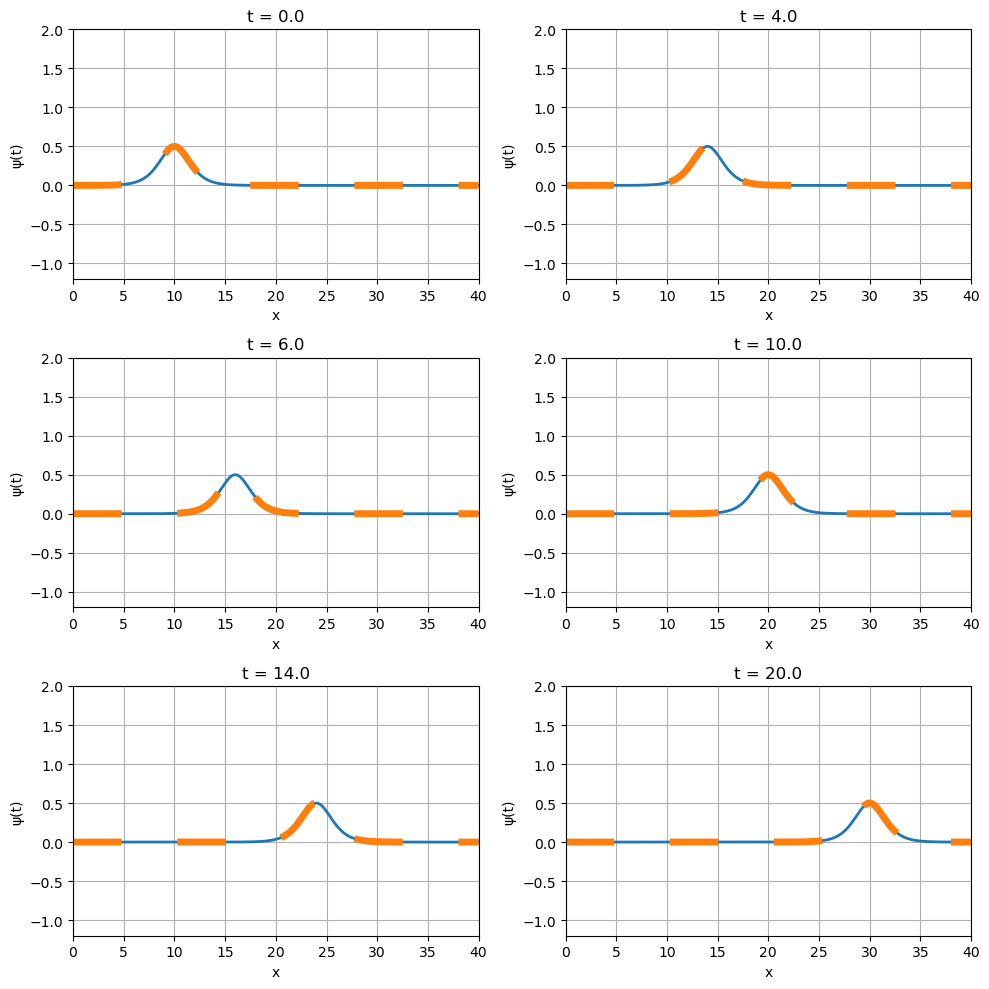

In [7]:
k = [0, 19999, 29999, 49999, 69999, 99999]

plt.figure(figsize=(10,10))

for idx,i in enumerate(k):

    plt.subplot(3,2,idx+1)

    plt.plot(x,
             KdVSoliton(x,dt*(i),c,10,NG),
             linewidth=2)

    line, = plt.plot(x,
                     y[i,:],
                     linewidth=5)
    line.set_dashes([7,8])

    plt.grid(True)
    plt.axis([np.min(x), np.max(x), -1.2, 2])

    plt.xlabel('x')
    plt.ylabel('ψ(t)')

    titletext = f"t = {t[i]:.1f}"
    plt.title(titletext)

plt.tight_layout()
plt.show()